In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# read the processed data
data = pd.read_csv("../data/processed/processed_data_low.csv")
data.head()

sd = data[data["RegionName"] == "Adrian, MI"]
sd

target = pd.Series(sd["MarketTemp"])

print(target)

train = target[:-16]
test = target[-16:]

lastvalue = train.iloc[1]
naive = np.repeat(lastvalue, len(test))

for i in naive:
    print(i)

4        108.0
908      115.0
1812     109.0
2715     103.0
3618      96.0
         ...  
58175     33.0
59107     29.0
60039     31.0
60971     36.0
61902     46.0
Name: MarketTemp, Length: 68, dtype: float64
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0
115.0


Same as ARIMA, flat result, due to the seasonality

In [ ]:

forecast = []
train_values = train.values

for i in range(len(test)):
    forecast.append(train_values[-12 + (i % 12)])
    
result = np.array(forecast)

print(result)

[39. 41. 47. 54. 59. 63. 69. 65. 56. 51. 48. 41. 39. 41. 47. 54.]
47943    32.0
48874    33.0
49804    32.0
50734    39.0
51664    48.0
52595    60.0
53526    60.0
54456    55.0
55386    51.0
56315    47.0
57245    38.0
58175    33.0
59107    29.0
60039    31.0
60971    36.0
61902    46.0
Name: MarketTemp, dtype: float64


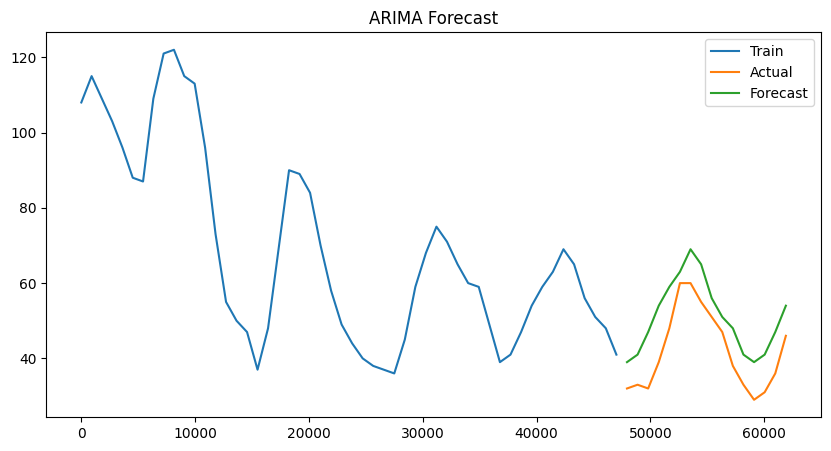

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("Seasonal Naive Forecast")
plt.show()